In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

In [3]:
from mytools import visualize_dag

In [4]:
sns.set_theme()

# Projects

In [5]:
projects=["C2012-13","C2014-03","C2015-12","C2015-15","C2015-16","C2015-17","C2015-18","C2015-19","C2015-21","C2015-22","C2015-23","C2015-26",
"C2016-42","C2017-06","C2018-10","C2018-13","C2019-04","C2019-05","C2019-06","C2019-11"]

C2012-13 Pumping Station Jabbeke.xlsx
AON graph with 74 nodes and 84 edges
Is a directed aclyclic grapk True


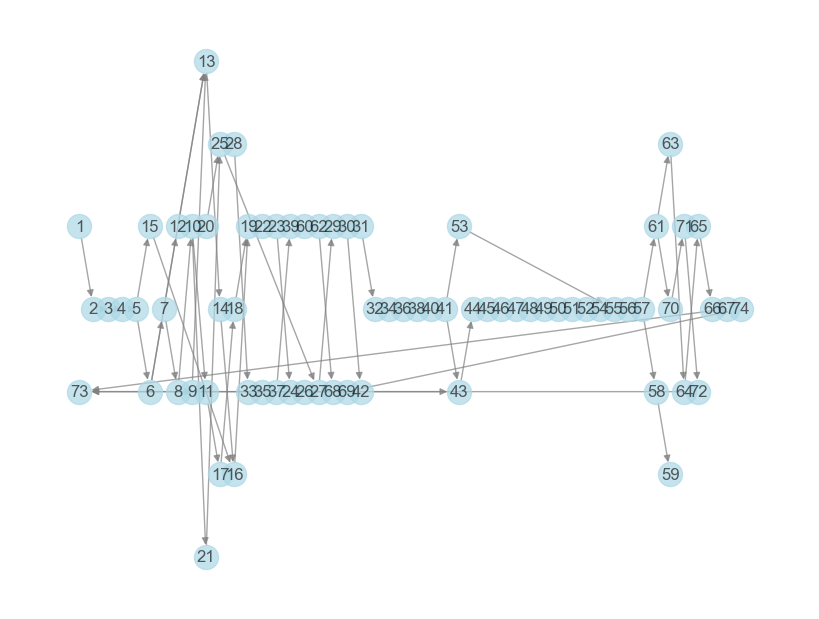

C2014-03 Organizational Development.xlsx
AON graph with 112 nodes and 97 edges
Is a directed aclyclic grapk True


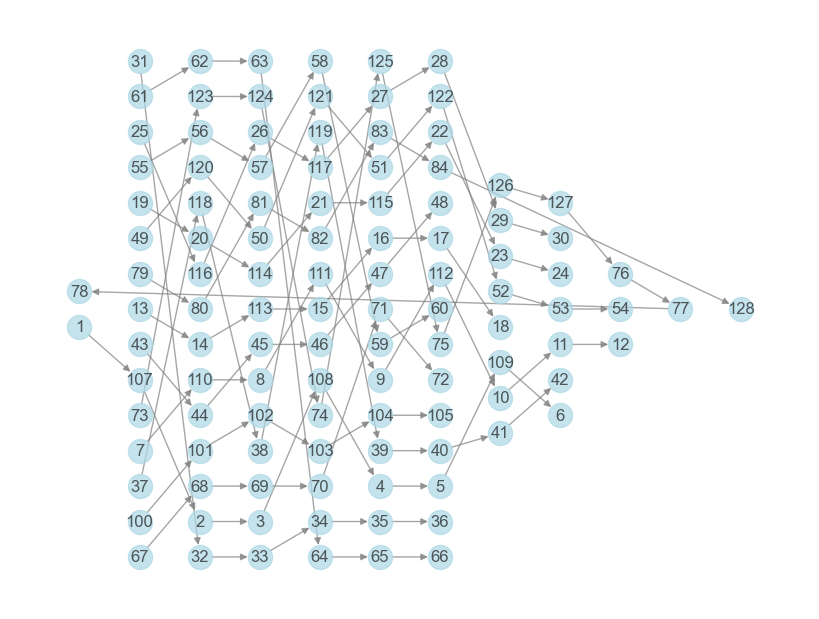

C2015-12 Premium Payment System.xlsx
AON graph with 40 nodes and 41 edges
Is a directed aclyclic grapk True


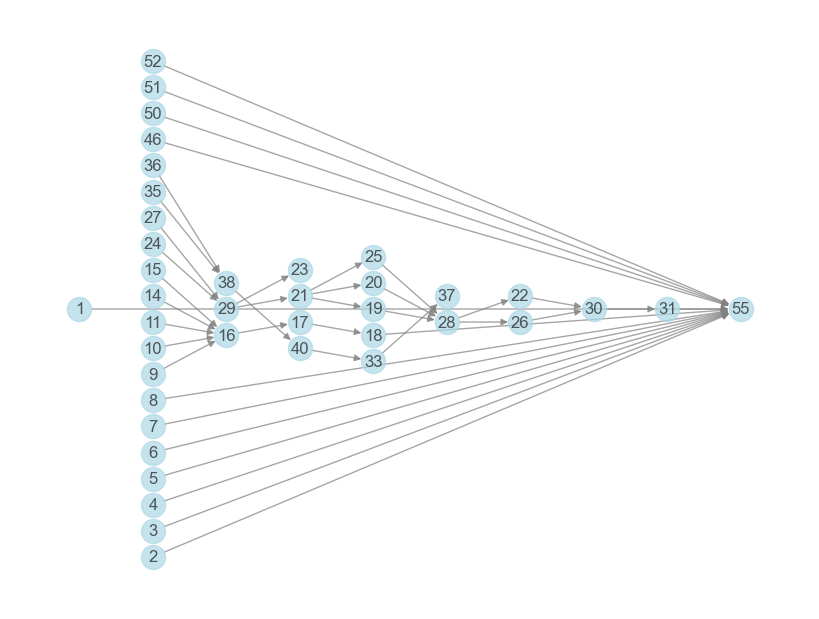

C2015-15 FACTA System.xlsx
AON graph with 19 nodes and 18 edges
Is a directed aclyclic grapk True


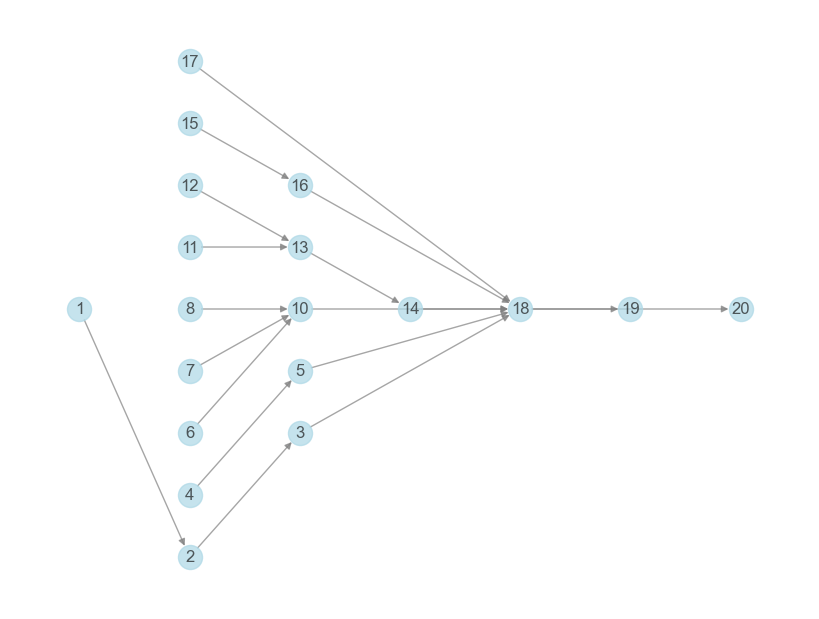

C2015-16 Generic Document Output System.xlsx
AON graph with 28 nodes and 45 edges
Is a directed aclyclic grapk True


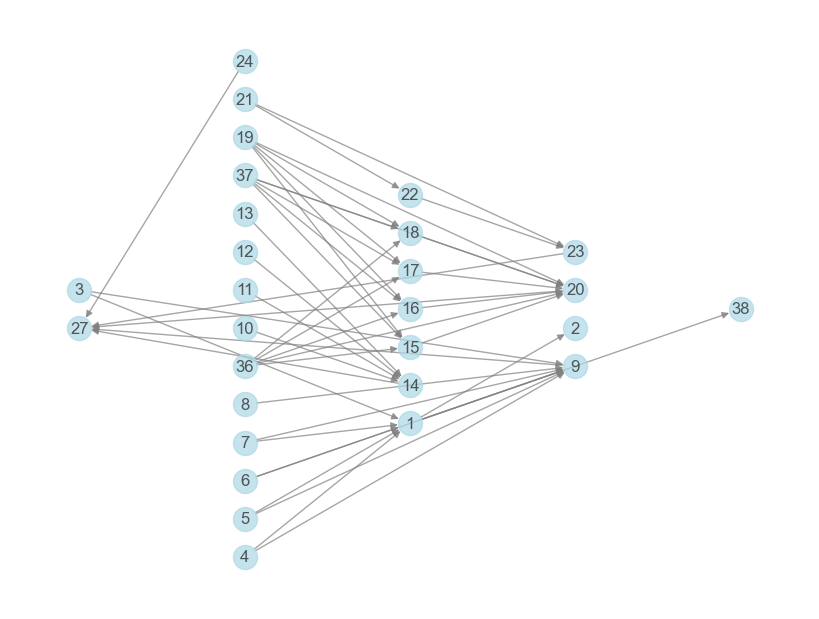

C2015-17 Insurance Bundling System.xlsx
AON graph with 89 nodes and 97 edges
Is a directed aclyclic grapk True


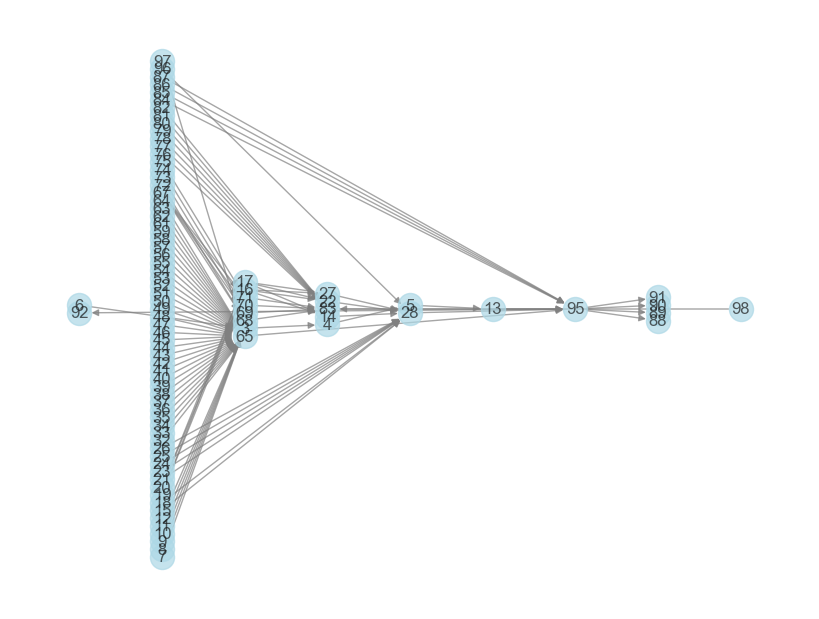

C2015-18 Tax Return System (2).xlsx
AON graph with 21 nodes and 19 edges
Is a directed aclyclic grapk True


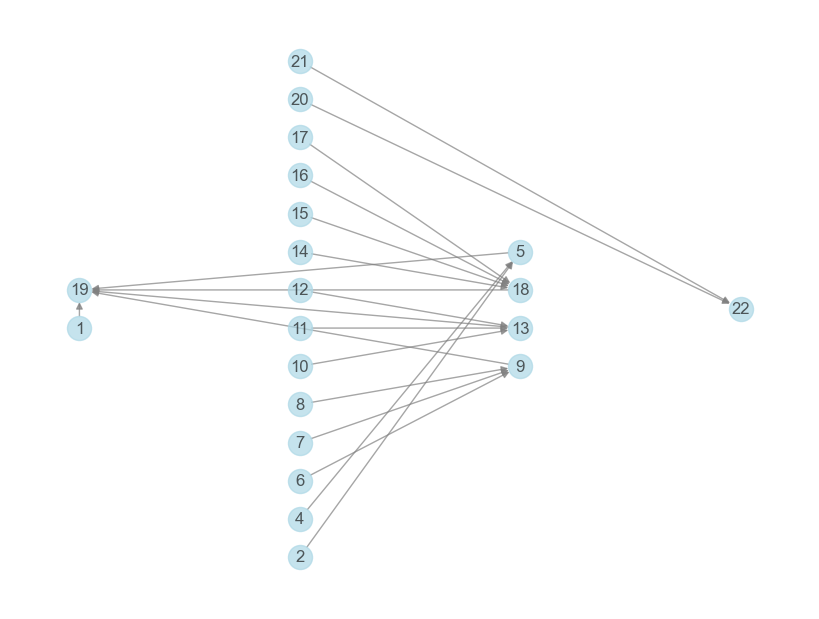

C2015-19 Receipt Numbering System.xlsx
AON graph with 24 nodes and 31 edges
Is a directed aclyclic grapk True


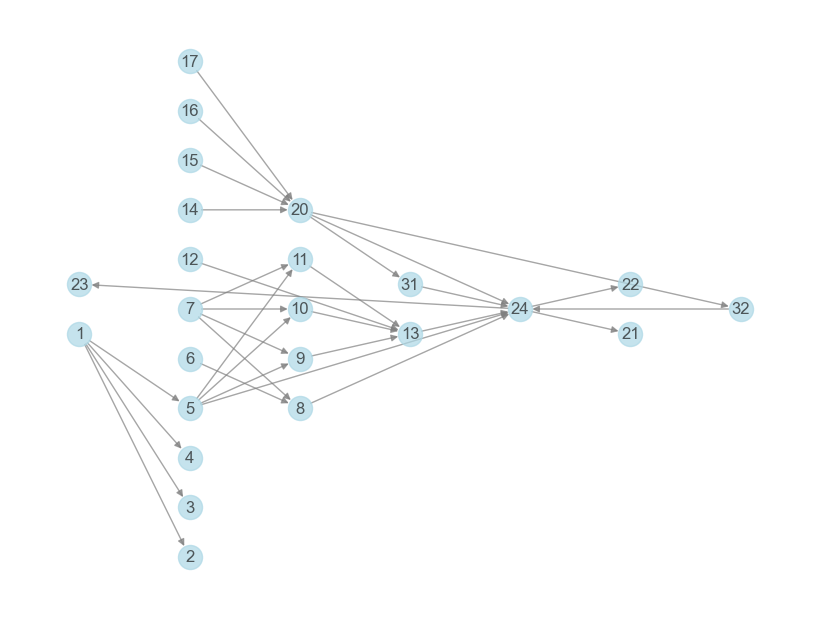

C2015-21 Investment Product (1).xlsx
AON graph with 17 nodes and 16 edges
Is a directed aclyclic grapk True


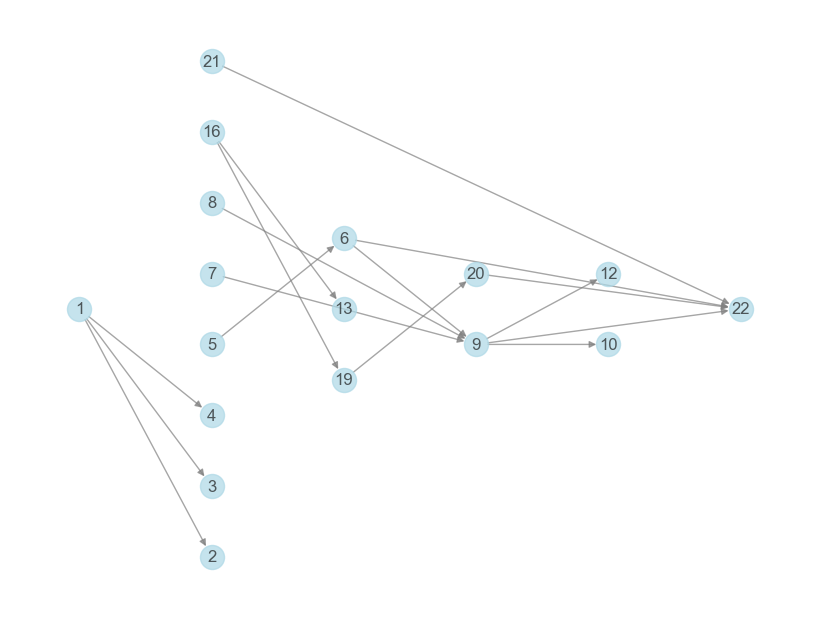

C2015-22 Risk Profile Questionnaire.xlsx
AON graph with 31 nodes and 38 edges
Is a directed aclyclic grapk True


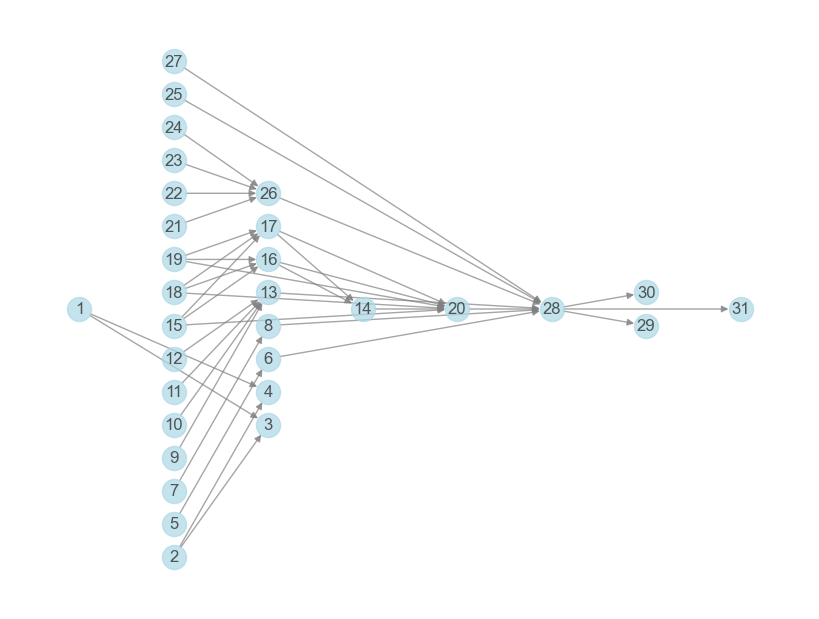

C2015-23 Investment Product (2).xlsx
AON graph with 40 nodes and 46 edges
Is a directed aclyclic grapk True


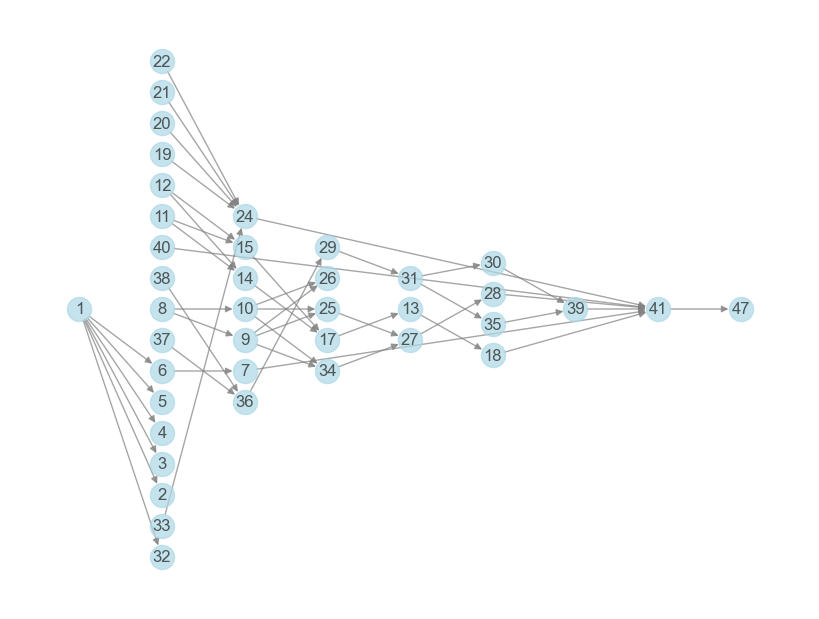

C2015-26 Debt Collection System.xlsx
AON graph with 182 nodes and 213 edges
Is a directed aclyclic grapk True


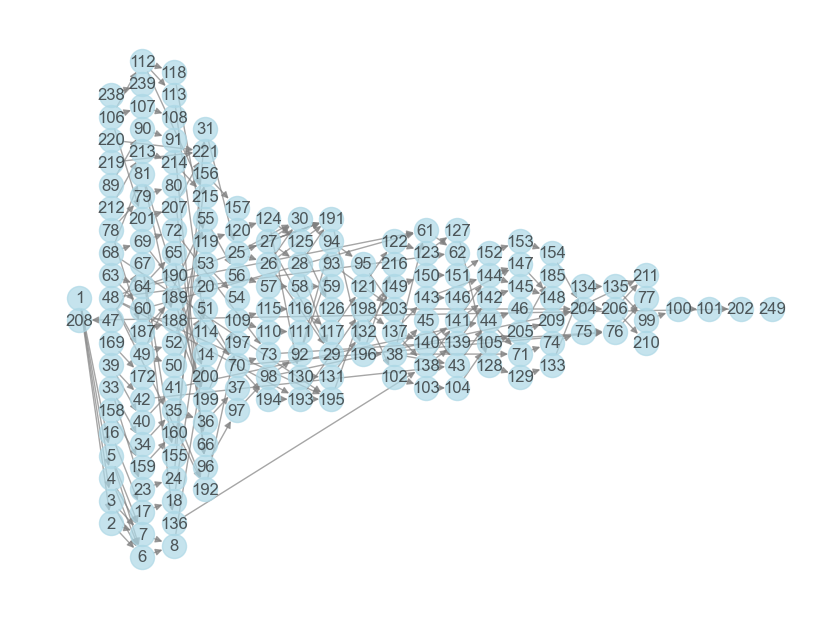

C2016-42 Shared bike app development.xlsx
AON graph with 32 nodes and 33 edges
Is a directed aclyclic grapk True


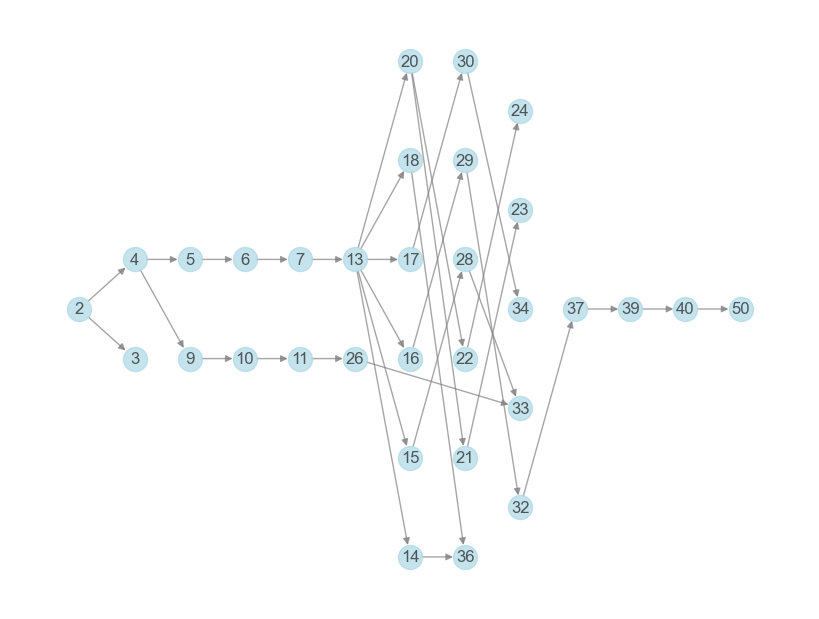

C2017-06 Landing gear development.xlsx
AON graph with 21 nodes and 25 edges
Is a directed aclyclic grapk True


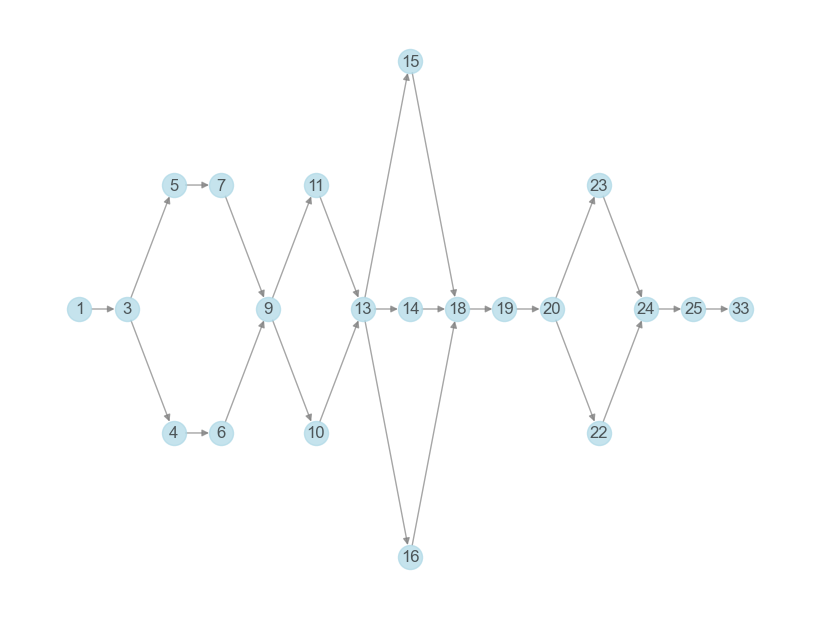

C2018-10 Fontein.xlsx
AON graph with 42 nodes and 54 edges
Is a directed aclyclic grapk True


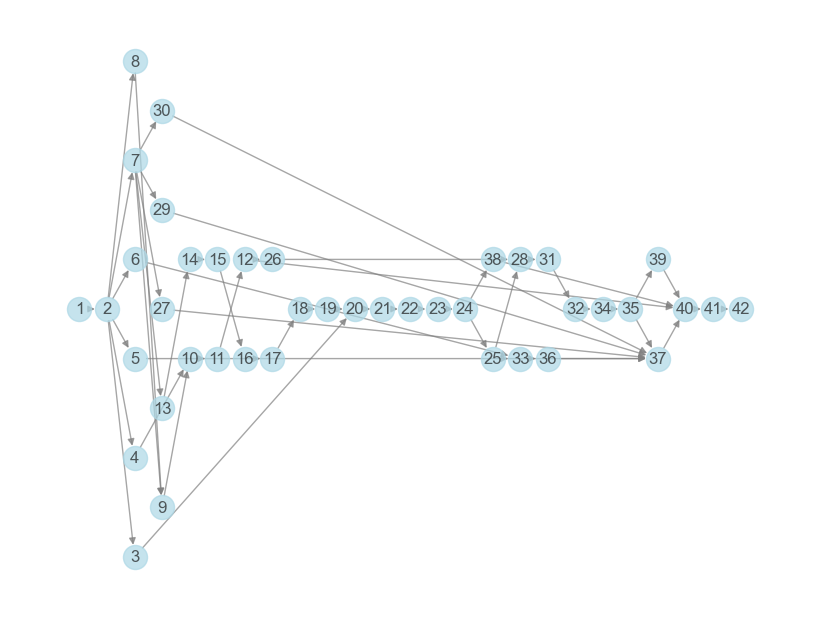

C2018-13 Christmas market.xlsx
AON graph with 33 nodes and 45 edges
Is a directed aclyclic grapk True


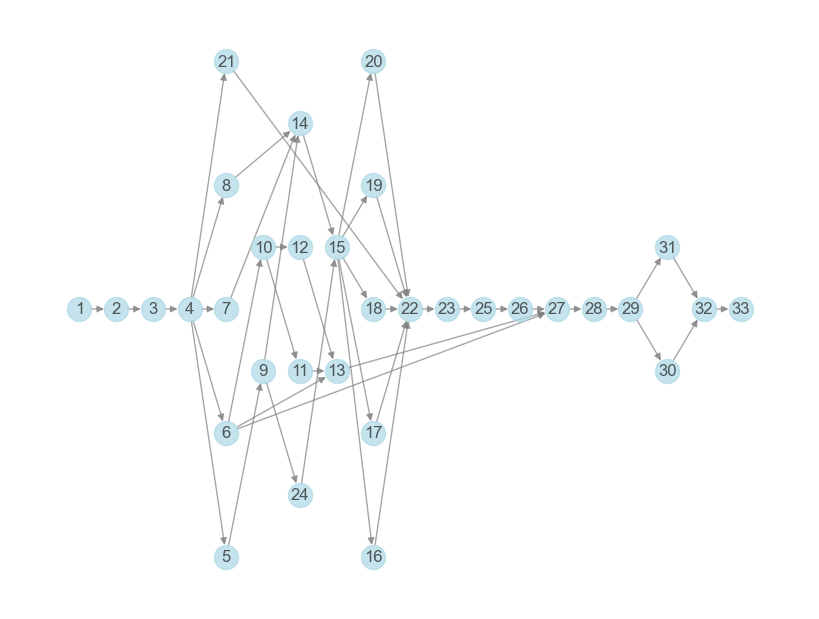

C2019-04 Nuclear Healthcare.xlsx
AON graph with 33 nodes and 38 edges
Is a directed aclyclic grapk True


c:\Users\jisma\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


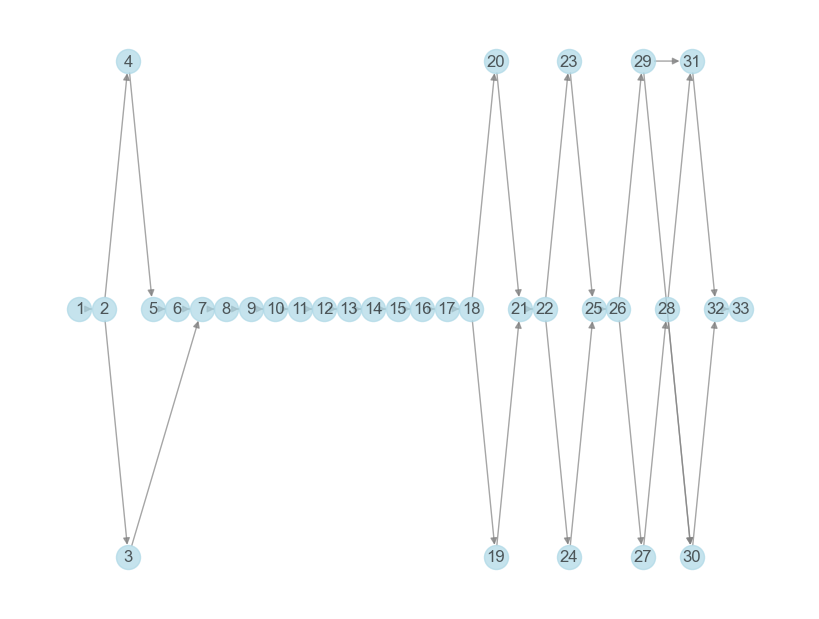

C2019-05 Fuel Tank Filter.xlsx
AON graph with 15 nodes and 23 edges
Is a directed aclyclic grapk True


c:\Users\jisma\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


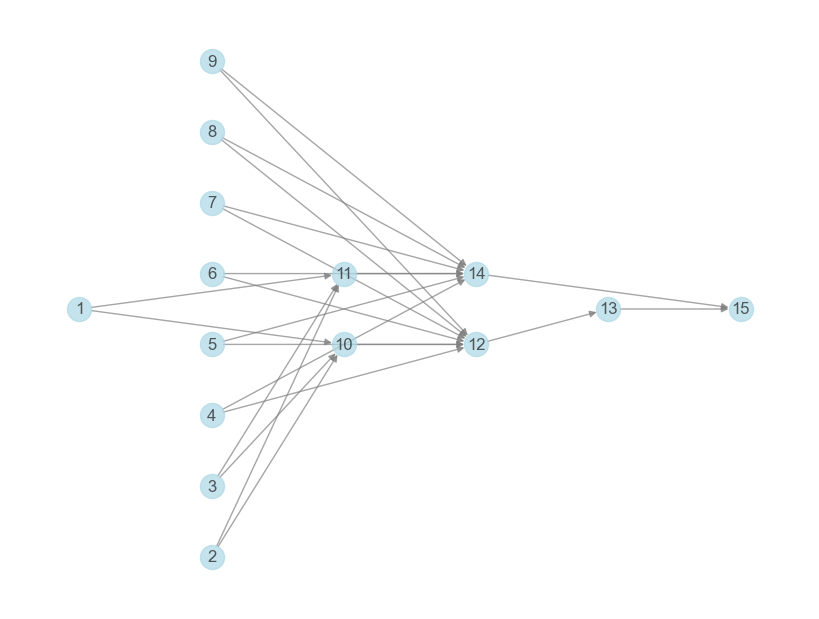

C2019-06 Production Line Change.xlsx
AON graph with 23 nodes and 34 edges
Is a directed aclyclic grapk True


c:\Users\jisma\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


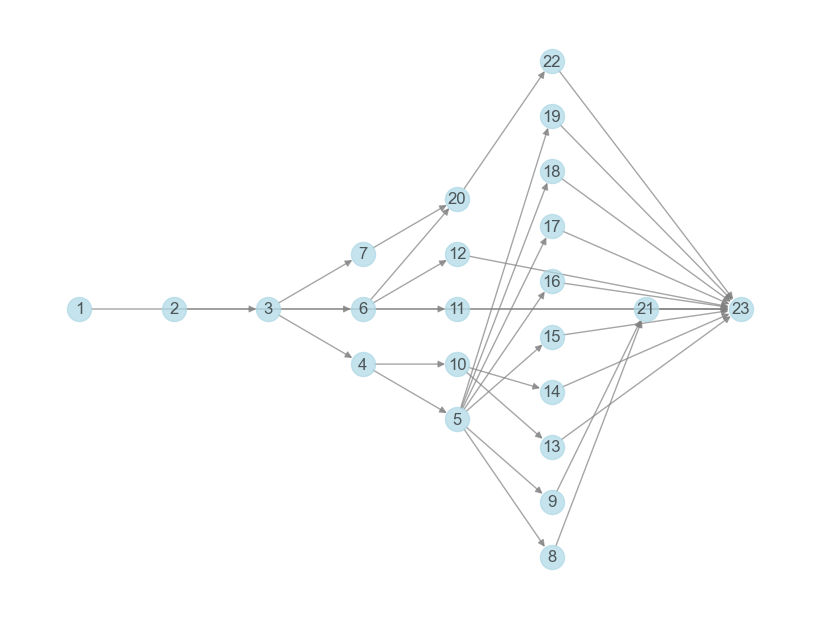

C2019-11 Tournament infrastructure.xlsx
AON graph with 30 nodes and 43 edges
Is a directed aclyclic grapk True


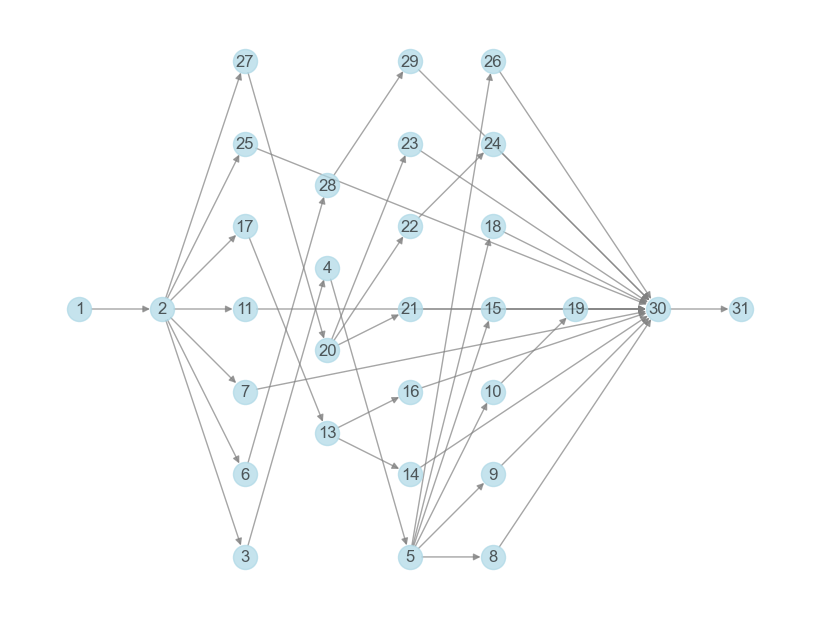

In [7]:
for project_index in projects:
    #print(project_index)
    for file_name in [file for file in os.listdir('dataset/') if project_index in file]:

        print(file_name)

        # Read the baseline schedule
        df_project=pd.read_excel('dataset/'+file_name, sheet_name='Baseline Schedule',skiprows=1,index_col=0,usecols='A:N')
        df_project.drop(0,axis=0,inplace=True) # drop the first row
        df_project.drop(df_project[df_project['Successors'].isna()].index[:-1],axis=0,inplace=True) # drop the rows with NaN successors  except the last row corresponding to the project completion

        # Build the Activity on Node (AON) network
        Go=nx.DiGraph()
        for i in df_project.index:
            Go.add_node(i)
            if not pd.isna(df_project.loc[i,'Successors']):
                for s in df_project.loc[i,'Successors'].split(";"):
                    if '+' in s:
                        s=s.split('+')[0] # remove information from the successor name
                    if '-' in s:
                        s=s.split('-')[0] # remove information from the successor name
                    Go.add_edge(i,int(s[2:]),type=s[:2])

        print(f'AON graph with {Go.number_of_nodes()} nodes and {Go.number_of_edges()} edges')
        print('Is a directed aclyclic grapk',nx.is_directed_acyclic_graph(Go))  

        # Visualize the AON network
        visualize_dag(Go)